# Arbitrage index

Given the reference trade sizes from `trade_sizes.ipynb`, price the **executable**
cross-pool round trip and summarize it into a per-pool-pair arbitrage index.

A real round trip closes the position: the second leg is the opposite side (sell
back what you bought) fed the real output of the first leg, so both fees and both
legs' slippage are charged. All logic lives in `arblib.arbitrage` / `arblib.plotting`.

In [1]:
from pathlib import Path

from arblib import data_io, analysis, sizing, arbitrage, plotting
from arblib.config import TOKENS

CHAIN = "ethereum"
DATA_DIR = Path.cwd() / CHAIN

# Processed per-pool series + spot mid price; constant USD rates; the trade-size refs.
pools = data_io.load_processed_pools(DATA_DIR / "processed")
analysis.add_mid_price(pools)

prices = data_io.load_usd_prices(DATA_DIR / "prices" / "USD_token_prices.csv")
const_usd = sizing.constant_usd_prices(prices)
usdc_usd = float(const_usd[TOKENS[CHAIN]["USDC"]])
weth_usd = float(const_usd[TOKENS[CHAIN]["WETH"]])

quantiles = data_io.load_quantiles(DATA_DIR / "trade_size_quantiles.csv")
print(quantiles)

Loaded 8 processed pools: ['uniswap_1', 'uniswap_2', 'uniswap_3', 'uniswap_4', 'uniswap_5', 'uniswap_6', 'pancake_1', 'pancake_2']
quantile
0.2      55.951689
0.4     297.702052
0.6     712.409333
0.8    1956.443754
Name: usd, dtype: float64


## 1. Cross-DEX mid-price gaps

The raw opportunity, before execution costs: reconstructed mid prices per pool and
the absolute price difference for every cross-DEX pool pair.

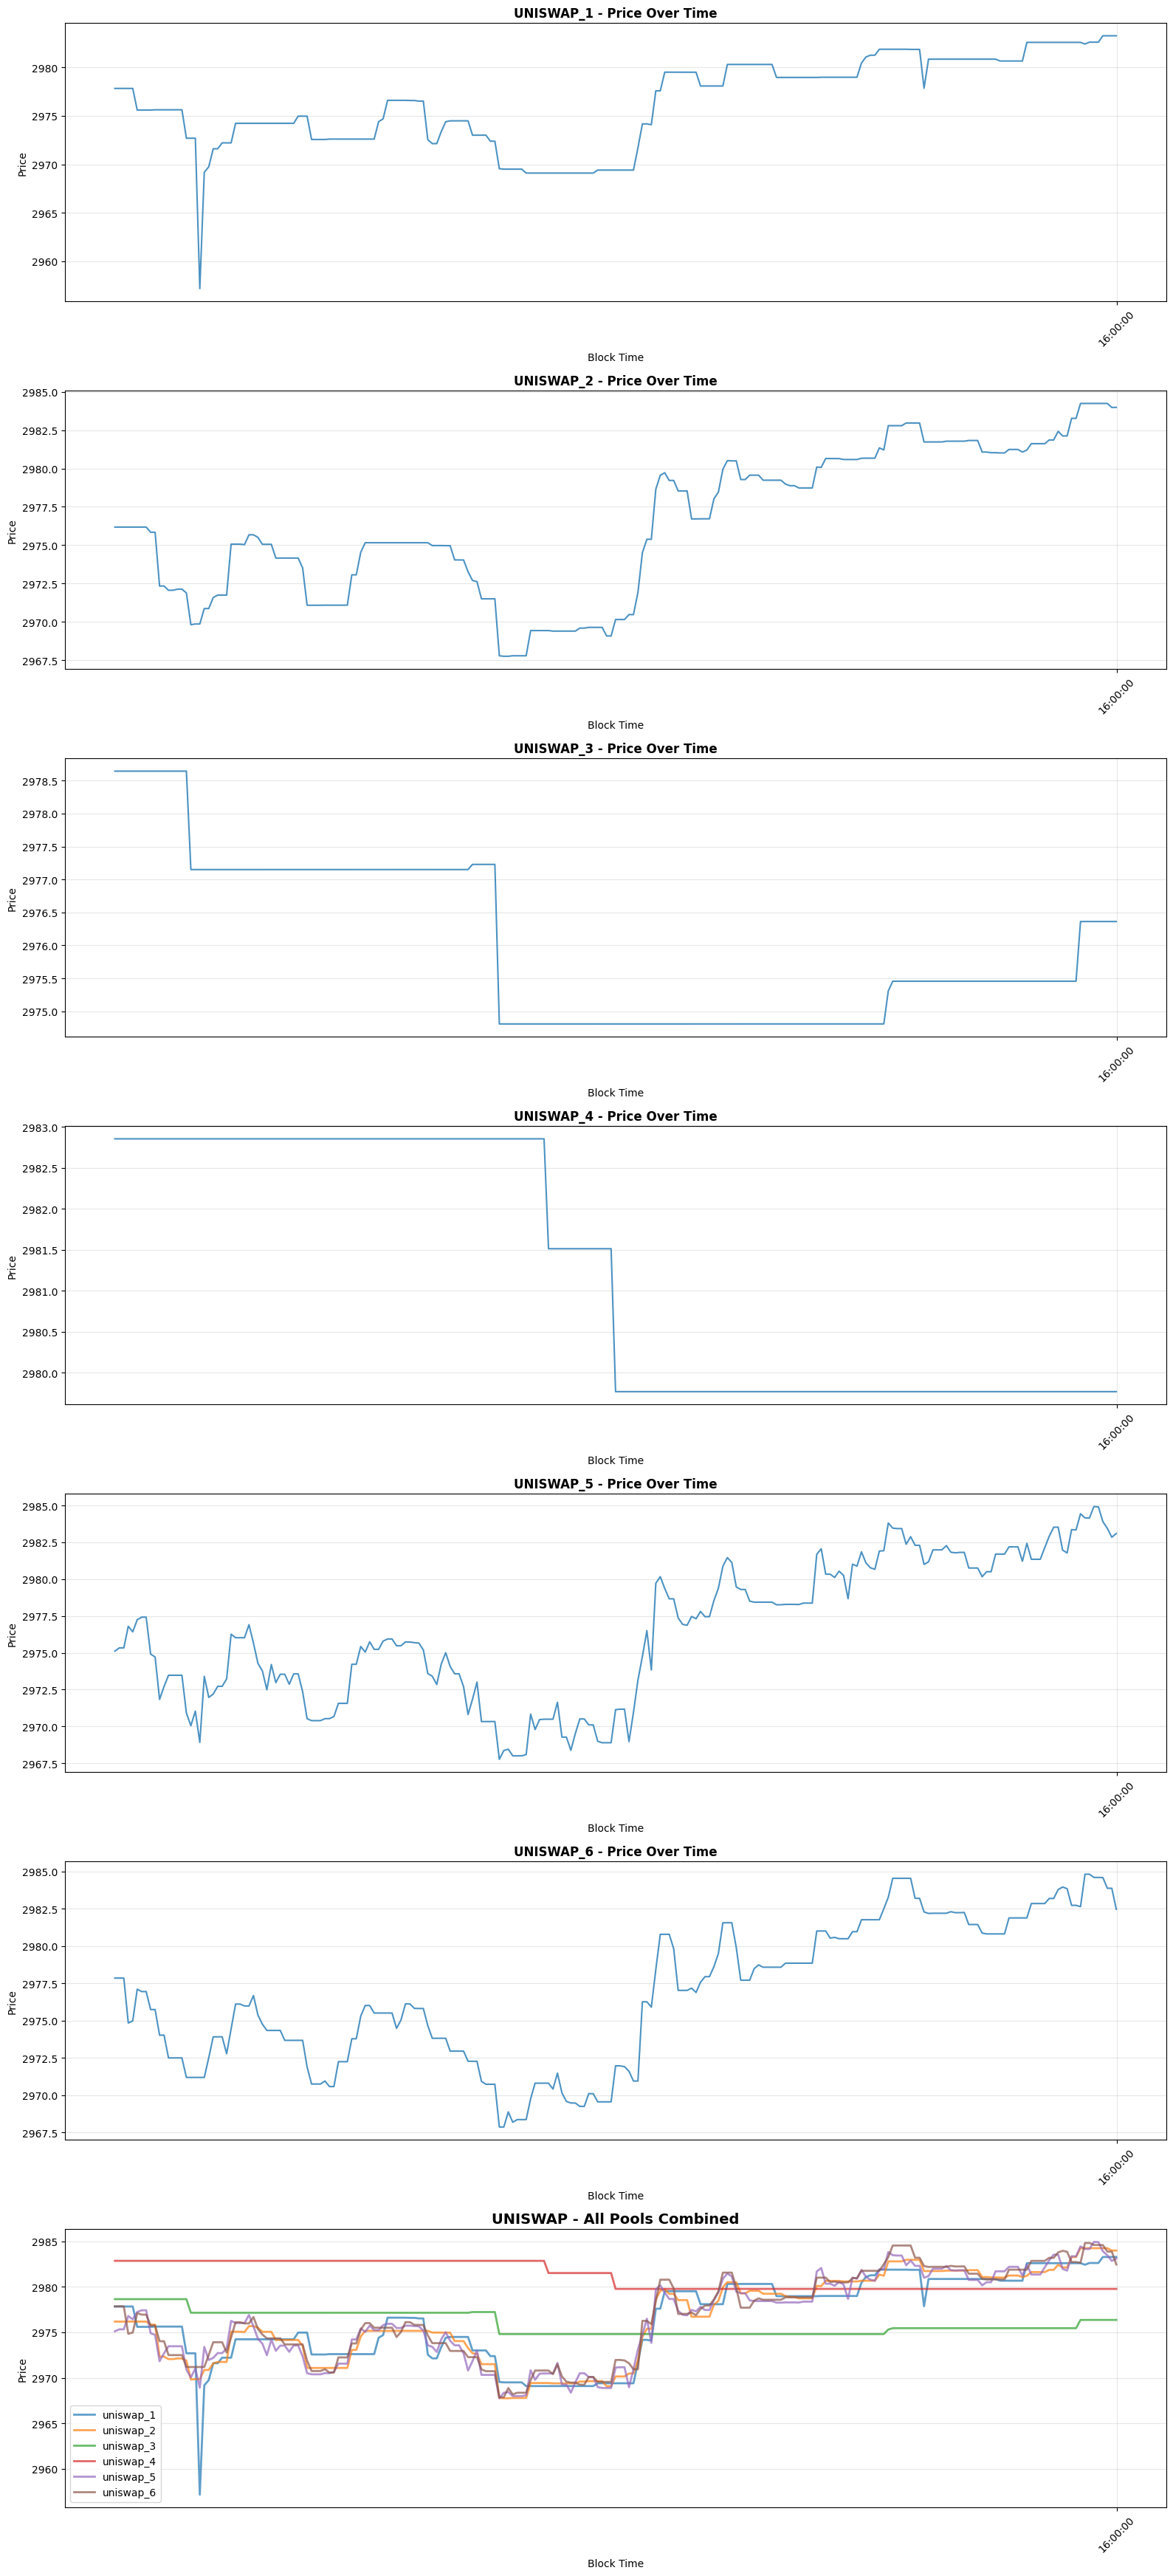


Plotted 6 uniswap pools + 1 combined view
  uniswap_1: 225 blocks
  uniswap_2: 225 blocks
  uniswap_3: 225 blocks
  uniswap_4: 225 blocks
  uniswap_5: 225 blocks
  uniswap_6: 225 blocks


In [2]:
plotting.plot_dex_pools(pools, dex="uniswap")

In [3]:
price_differences, all_price_differences = analysis.compute_pairwise_differences(pools)

DEXes found: ['uniswap', 'pancake']
Pools per DEX: [('uniswap', 6), ('pancake', 2)]

Computed 12 pairwise comparisons:

uniswap_1_vs_pancake_1:
  Rows: 225
  Max diff: 12.931532
  Mean diff: 1.391070
  Min diff: 0.019574

uniswap_1_vs_pancake_2:
  Rows: 225
  Max diff: 12.718176
  Mean diff: 1.015642
  Min diff: 0.010093

uniswap_2_vs_pancake_1:
  Rows: 225
  Max diff: 2.730908
  Mean diff: 0.836662
  Min diff: 0.010508

uniswap_2_vs_pancake_2:
  Rows: 225
  Max diff: 2.434724
  Mean diff: 0.555870
  Min diff: 0.000000

uniswap_3_vs_pancake_1:
  Rows: 225
  Max diff: 8.747698
  Mean diff: 4.804879
  Min diff: 0.385545

uniswap_3_vs_pancake_2:
  Rows: 225
  Max diff: 7.560673
  Mean diff: 4.859384
  Min diff: 0.295219

uniswap_4_vs_pancake_1:
  Rows: 225
  Max diff: 16.792415
  Mean diff: 6.217794
  Min diff: 0.091231

uniswap_4_vs_pancake_2:
  Rows: 225
  Max diff: 15.605390
  Mean diff: 6.046429
  Min diff: 0.186214

uniswap_5_vs_pancake_1:
  Rows: 225
  Max diff: 4.224619
  Mean diff

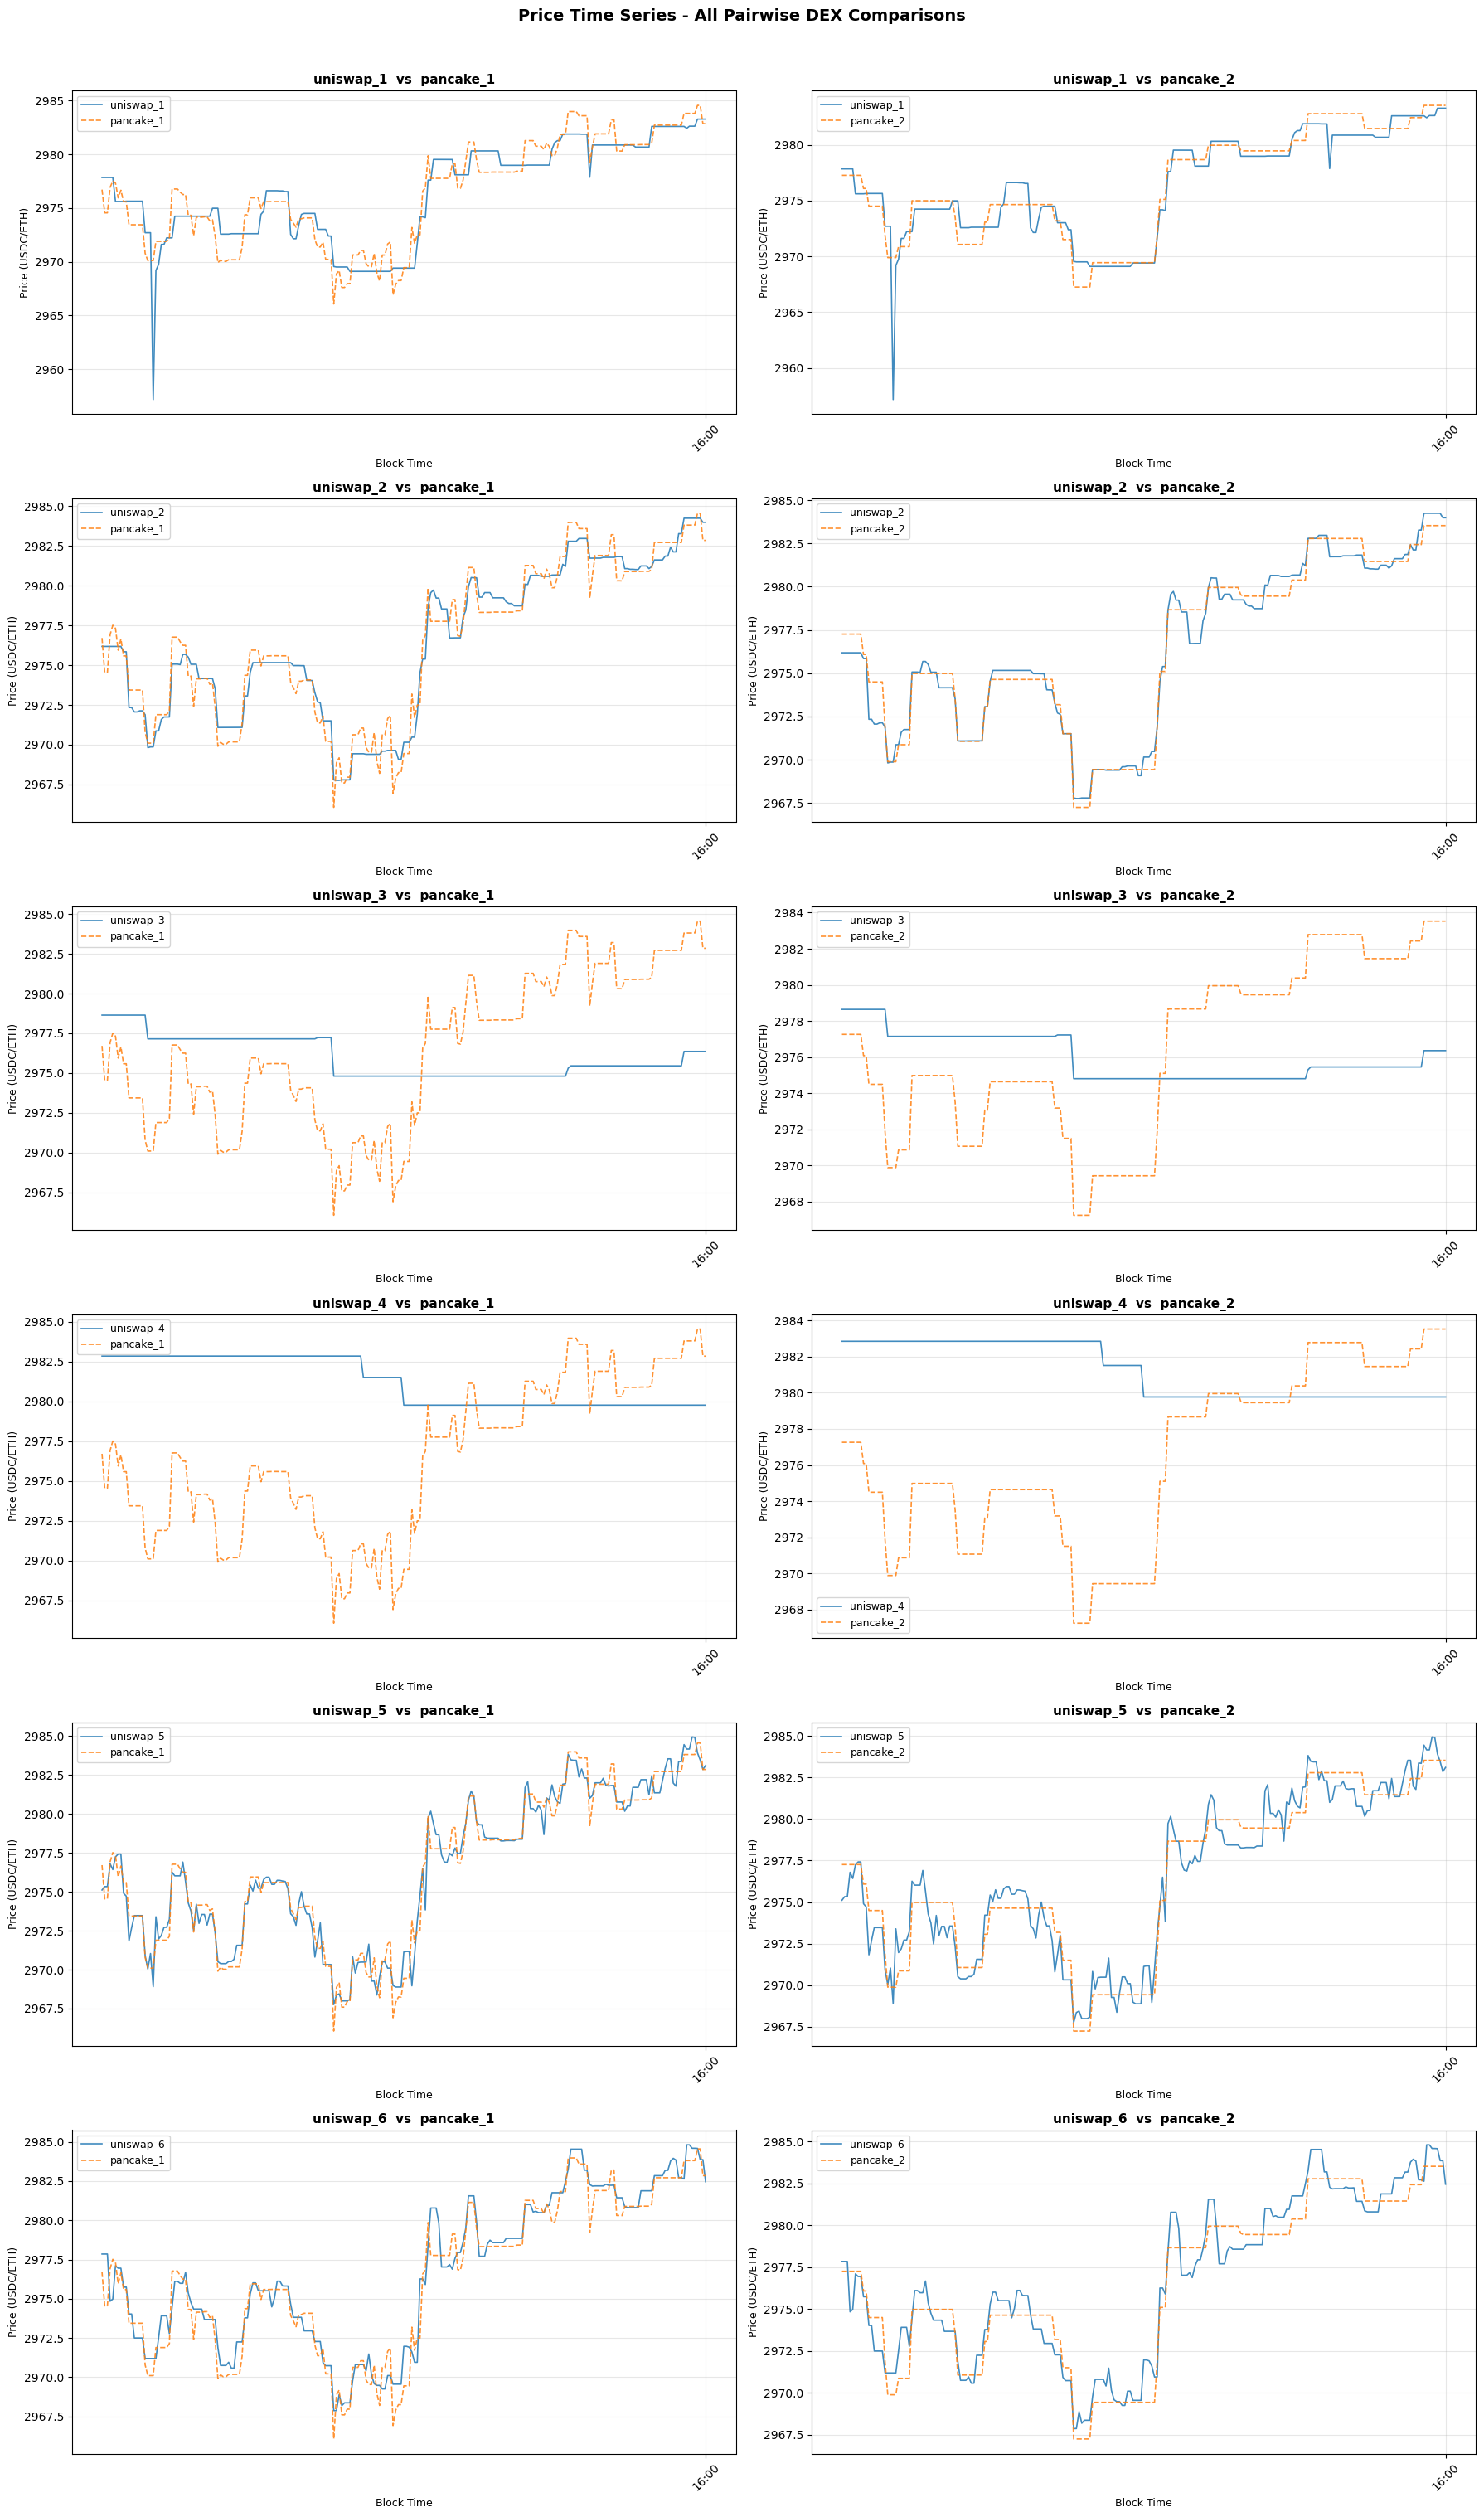

In [4]:
plotting.plot_pairwise_prices(price_differences)

## 2. Pick a pool pair

Bundle two pools' per-block state + market context into a `PoolPair`.

In [5]:
pair = arbitrage.build_pool_pair(
    pools["pancake_1"], pools["uniswap_1"], usdc_usd, weth_usd, "pancake_1", "uniswap_1"
)

## 3. Round-trip spreads at each reference trade size

Two panels per size (direction 1→2 and 2→1, Y- and X-anchored). A series
**below** zero is a profitable round trip after both fees + slippage.

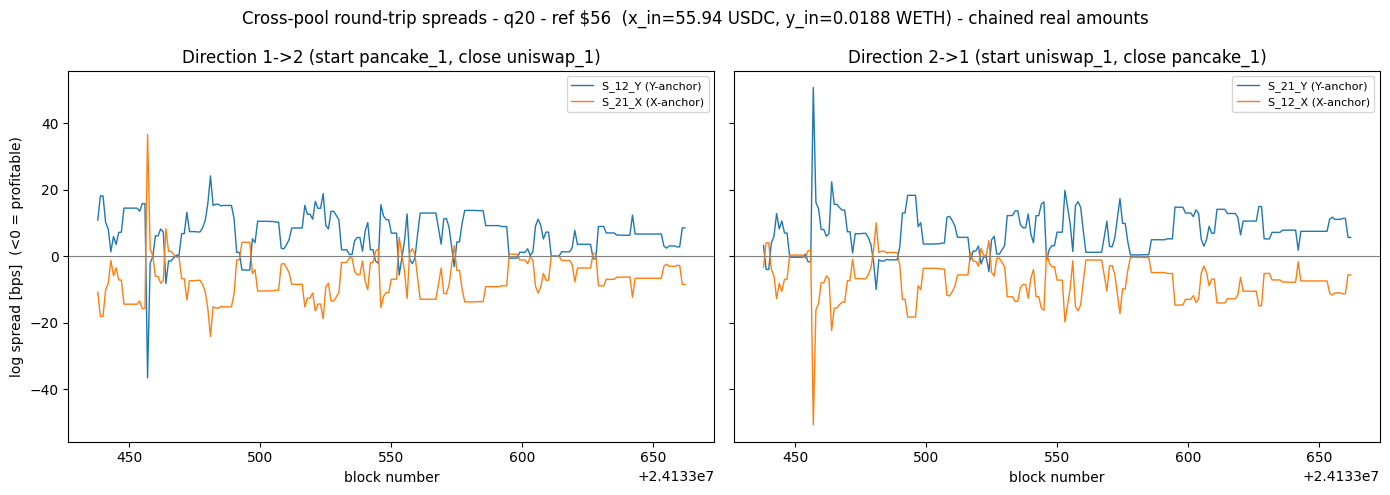

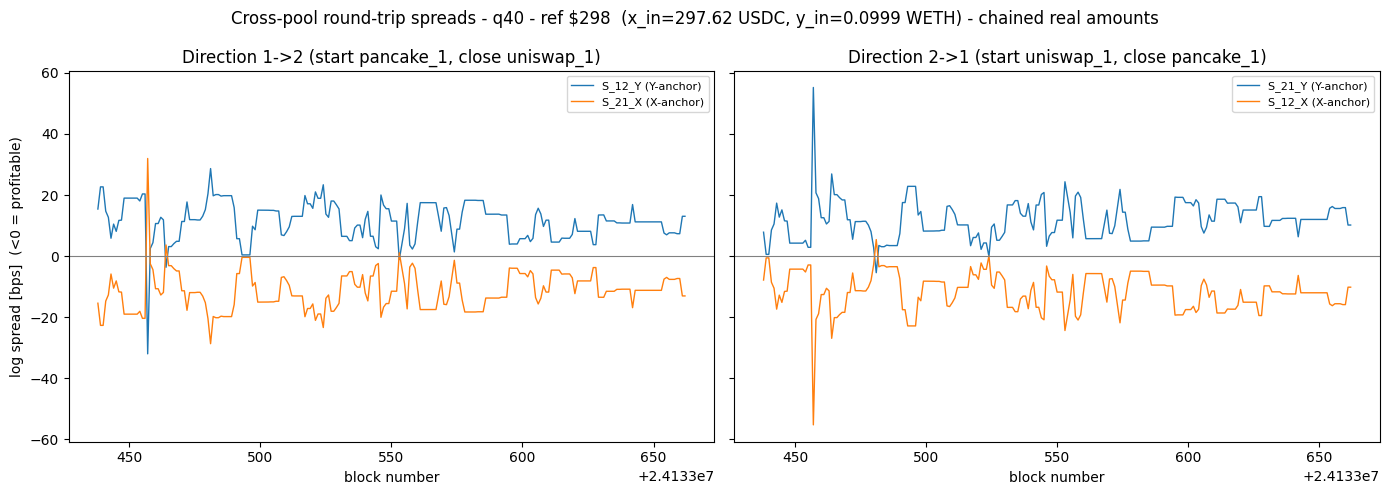

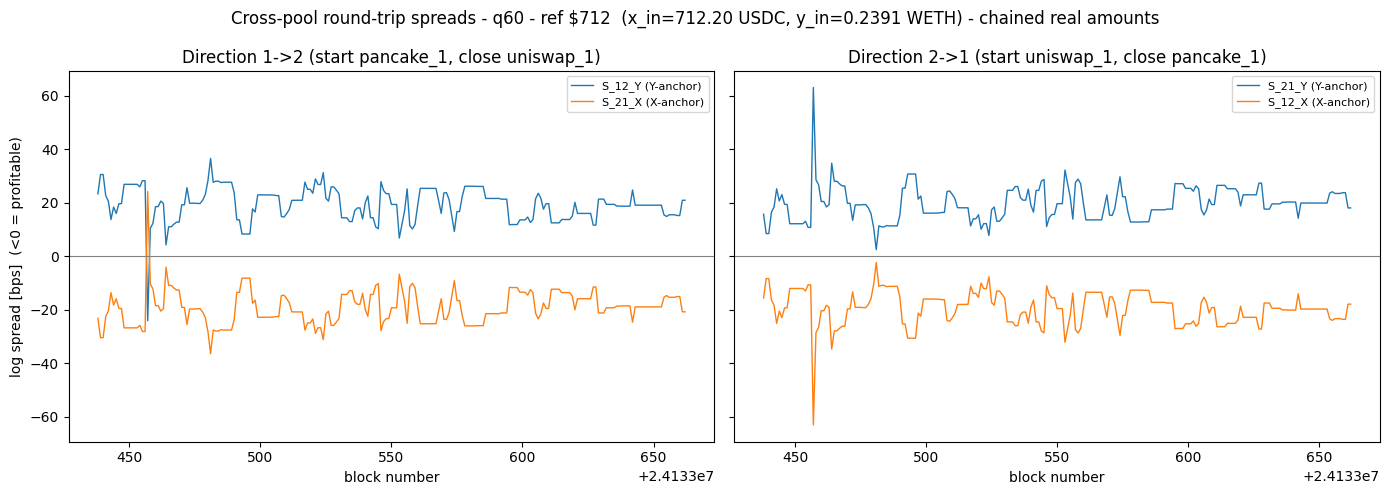

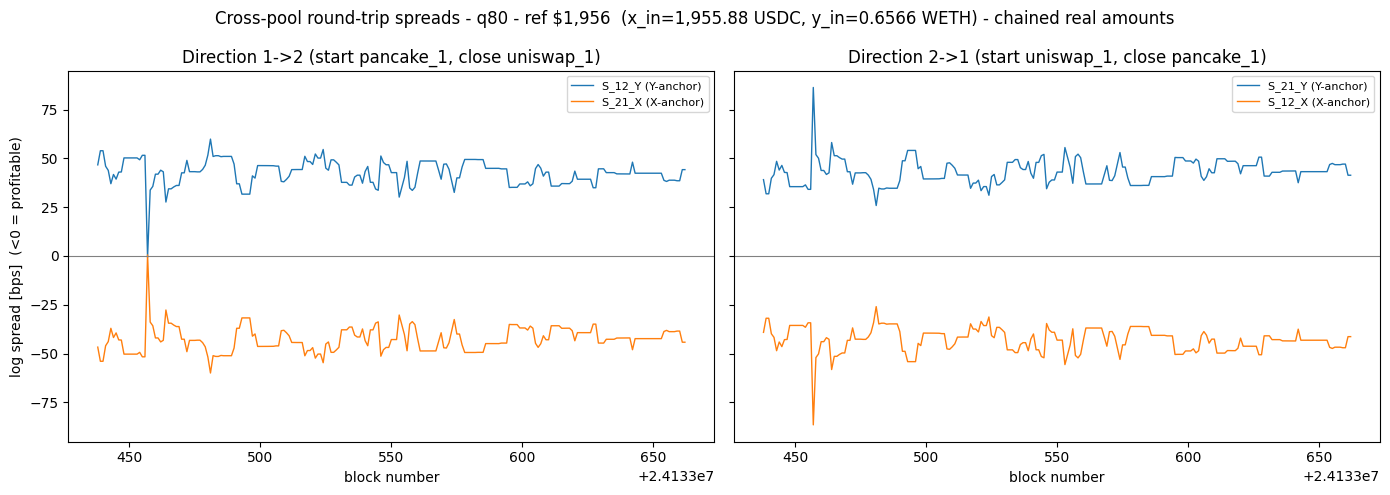

In [6]:
for q, Q in quantiles.items():
    plotting.plot_directional_spreads(pair, Q, f"Cross-pool round-trip spreads - q{int(q * 100)}")

## 4. Arbitrage index

Per reference size: how often a round-trip gap is live and how big it is (bps).
This per-pair table is the signal a downstream model stacks over every pool pair.

In [7]:
arbitrage.arbitrage_index(pair, quantiles)

,usd_ref,n_blocks,live_gap_share,mean_gap_bps,median_gap_bps,max_gap_bps,anchor_agreement
quantile,,,,,,,
0.2,55.951689,225,0.226667,0.589778,0.0,36.574824,1.0
0.4,297.702052,225,0.022222,0.188127,0.0,32.004891,1.0
0.6,712.409333,225,0.004444,0.107424,0.0,24.170324,1.0
0.8,1956.443754,225,0.004444,0.003133,0.0,0.705033,1.0


## 5. Custom trade size

Same pipeline at any size: pass exactly one of `usd_amount` / `x_amount` (USDC) /
`y_amount` (WETH).

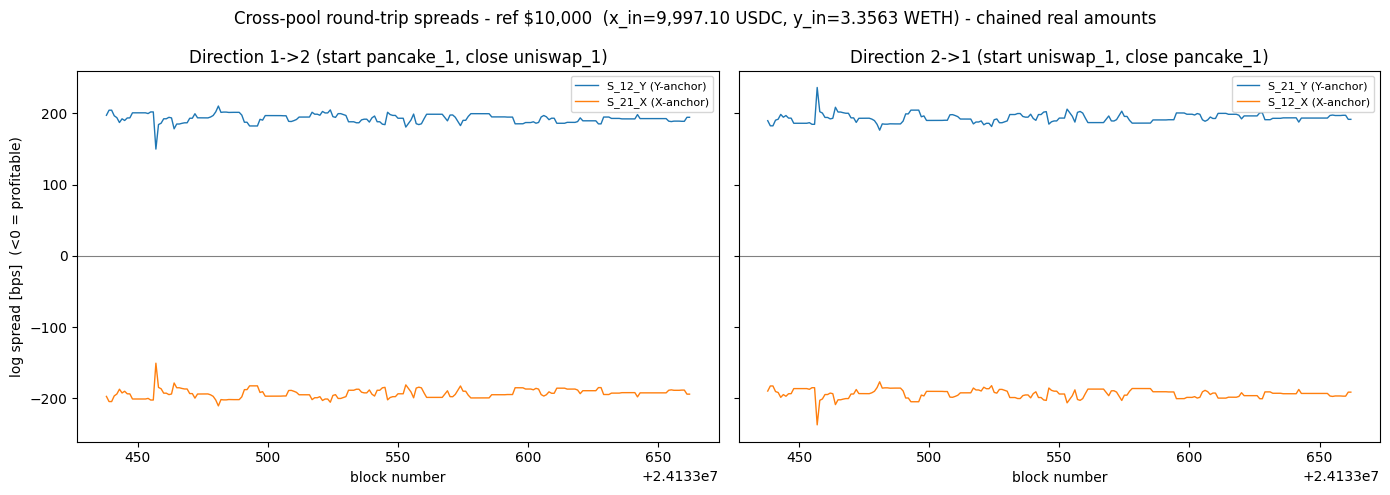

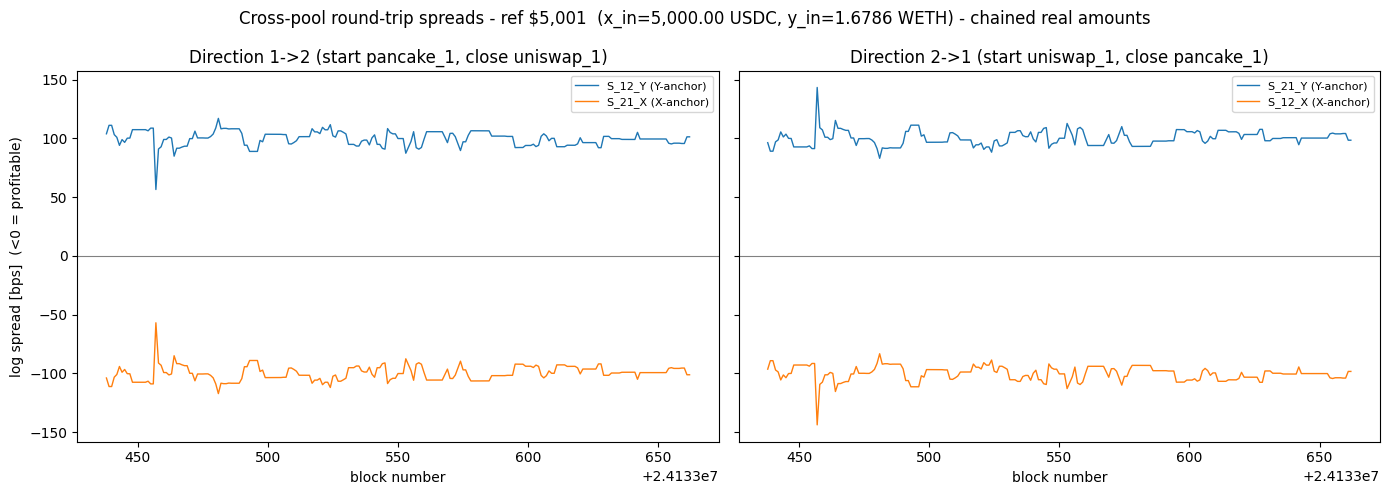

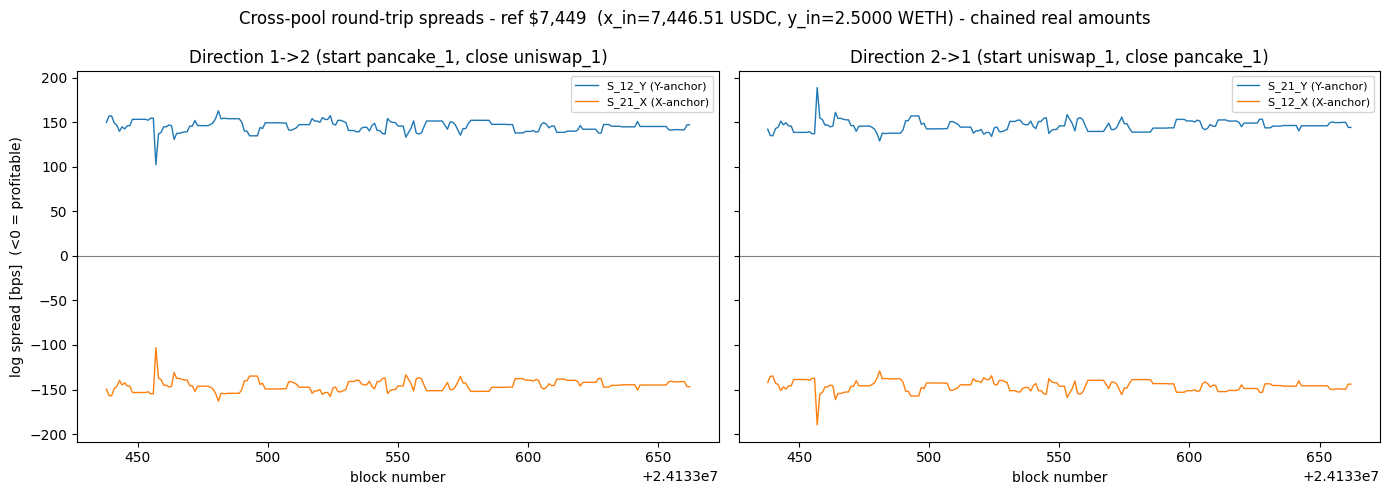

In [8]:
plotting.plot_custom_size(pair, usd_amount=10_000, title_prefix="Cross-pool round-trip spreads")
plotting.plot_custom_size(pair, x_amount=5_000, title_prefix="Cross-pool round-trip spreads")   # 5,000 USDC
plotting.plot_custom_size(pair, y_amount=2.5, title_prefix="Cross-pool round-trip spreads")     # 2.5 WETH